In [2]:
from pathlib import Path
import rdata

file_path = Path("3Dnetworks.RData")

parsed = rdata.parser.parse_file(file_path)
data = rdata.conversion.convert(parsed)

print(type(data))
print(data.keys())

/opt/anaconda3/envs/spine-analysis/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "hyperframe". The constructor for class "list" will be used instead.
  warnings.warn(
/opt/anaconda3/envs/spine-analysis/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "list". The underlying R object is returned instead.
  warnings.warn(
/opt/anaconda3/envs/spine-analysis/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "units". The underlying R object is returned instead.
  warnings.warn(
/opt/anaconda3/envs/spine-analysis/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "box3". The underlying R object is returned instead.
  warnings.warn(
/opt/anaconda3/envs/spine-analysis/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing co

<class 'dict'>
dict_keys(['basal', 'apical', '.Random.seed'])


/opt/anaconda3/envs/spine-analysis/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "hyperframe". The constructor for class "list" will be used instead.
  warnings.warn(
/opt/anaconda3/envs/spine-analysis/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "list". The underlying R object is returned instead.
  warnings.warn(
/opt/anaconda3/envs/spine-analysis/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "units". The underlying R object is returned instead.
  warnings.warn(
/opt/anaconda3/envs/spine-analysis/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "box3". The underlying R object is returned instead.
  warnings.warn(
/opt/anaconda3/envs/spine-analysis/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing co

In [3]:
for name in ["basal", "apical"]:
    obj = data[name]

    print("=" * 80)
    print("Название:", name)
    print("Python-тип:", type(obj))

    if isinstance(obj, dict):
        print("Ключи:", list(obj.keys()))

    elif isinstance(obj, (list, tuple)):
        print("Количество элементов:", len(obj))
        print("Тип первого элемента:", type(obj[0]) if obj else None)

    print(repr(obj)[:2000])

Название: basal
Python-тип: <class 'dict'>
Ключи: ['nvars', 'ncases', 'vname', 'vtype', 'vclass', 'df', 'hyperatoms', 'hypercolumns']
{'nvars': array([3]), 'ncases': array([17.]), 'vname': ['vertices', 'm', 'X'], 'vtype': ['hypercolumn', 'hypercolumn', 'hypercolumn']
Categories (3, object): ['dfcolumn', 'hypercolumn', 'hyperatom'], 'vclass': ['pp3', 'matrix', 'pp3'], 'df': Empty DataFrame
Columns: []
Index: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], 'hyperatoms': [], 'hypercolumns': {'vertices': [{'data': {'nvars': array([3]), 'ncases': array([1605.]), 'vname': ['x', 'y', 'z'], 'vtype': ['dfcolumn', 'dfcolumn', 'dfcolumn']
Categories (3, object): ['dfcolumn', 'hypercolumn', 'hyperatom'], 'vclass': ['numeric', 'numeric', 'numeric'], 'df':                x           y          z
1     313.879425  332.641023   9.830313
2     309.450013  334.973999  12.247500
3     305.151001  336.578003  14.337700
4     300.518005  338.397003  16.125500
5     295.985991  339.889006  18.0

In [4]:
from pathlib import Path
from typing import Any, Dict, Optional, Tuple

import json
import warnings

import numpy as np
import pandas as pd
import rdata


RDATA_PATH = Path("3Dnetworks.RData")
OUTPUT_DIR = Path("3Dnetworks_export")


def load_rdata(file_path: Path) -> Dict[str, Any]:
    """Читает .RData через API, доступный в rdata 0.9."""

    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message='Missing constructor for R class.*',
        )

        parsed = rdata.parser.parse_file(file_path)
        converted = rdata.conversion.convert(parsed)

    if not isinstance(converted, dict):
        raise TypeError(
            f"Ожидался словарь объектов R, получено: {type(converted)}"
        )

    return converted


def extract_pp3_dataframe(obj: Dict[str, Any]) -> pd.DataFrame:
    """
    Извлекает координаты x, y, z из преобразованного R-объекта pp3.
    """

    try:
        dataframe = obj["data"]["df"]
    except (KeyError, TypeError) as error:
        raise ValueError(
            "Не удалось найти таблицу координат по пути obj['data']['df']"
        ) from error

    if not isinstance(dataframe, pd.DataFrame):
        raise TypeError(
            f"Ожидался pandas.DataFrame, получено: {type(dataframe)}"
        )

    required_columns = {"x", "y", "z"}

    if not required_columns.issubset(dataframe.columns):
        raise ValueError(
            f"Ожидались столбцы {sorted(required_columns)}, "
            f"получены {list(dataframe.columns)}"
        )

    result = dataframe.loc[:, ["x", "y", "z"]].copy()
    result = result.reset_index(drop=True)

    for column in ["x", "y", "z"]:
        result[column] = pd.to_numeric(result[column], errors="raise")

    return result


def find_2d_array(obj: Any) -> Optional[np.ndarray]:
    """
    Рекурсивно ищет двумерную матрицу внутри преобразованного R-объекта.
    """

    if isinstance(obj, pd.DataFrame):
        array = obj.to_numpy()

        if array.ndim == 2:
            return array

    if isinstance(obj, np.ndarray):
        array = np.asarray(obj)

        if array.ndim == 2:
            return array

    if isinstance(obj, (list, tuple)):
        try:
            array = np.asarray(obj)

            if array.ndim == 2 and array.dtype != object:
                return array
        except (TypeError, ValueError):
            pass

        for value in obj:
            result = find_2d_array(value)

            if result is not None:
                return result

    if isinstance(obj, dict):
        # Сначала проверяем наиболее вероятные поля.
        for key in ["data", "df", "values", "matrix", "array"]:
            if key in obj:
                result = find_2d_array(obj[key])

                if result is not None:
                    return result

        # Затем проверяем остальные поля.
        for key, value in obj.items():
            if key in {"data", "df", "values", "matrix", "array"}:
                continue

            result = find_2d_array(value)

            if result is not None:
                return result

    return None


def extract_matrix(obj: Any) -> np.ndarray:
    """Извлекает матрицу m."""

    matrix = find_2d_array(obj)

    if matrix is None:
        raise ValueError(
            "Не удалось найти двумерную матрицу внутри объекта m"
        )

    matrix = np.asarray(matrix)

    if matrix.ndim != 2:
        raise ValueError(
            f"Матрица должна быть двумерной, получена форма {matrix.shape}"
        )

    return matrix


def normalize_edge_indices(
    edges: pd.DataFrame,
    n_vertices: int,
) -> Tuple[pd.DataFrame, str]:
    """
    Переводит индексы рёбер в нумерацию с нуля.

    Если исходные индексы лежат в диапазоне 1..N, предполагается,
    что используется стандартная R-нумерация с единицы.
    """

    result = edges.copy()

    result["source"] = pd.to_numeric(
        result["source"],
        errors="raise",
    ).astype(int)

    result["target"] = pd.to_numeric(
        result["target"],
        errors="raise",
    ).astype(int)

    minimum = min(
        result["source"].min(),
        result["target"].min(),
    )

    maximum = max(
        result["source"].max(),
        result["target"].max(),
    )

    if minimum >= 1 and maximum <= n_vertices:
        result["source"] -= 1
        result["target"] -= 1
        indexing = "converted_from_R_1_based_to_0_based"

    elif minimum >= 0 and maximum < n_vertices:
        indexing = "already_0_based"

    else:
        raise ValueError(
            "Индексы рёбер выходят за допустимый диапазон: "
            f"min={minimum}, max={maximum}, "
            f"число вершин={n_vertices}"
        )

    return result, indexing


def matrix_to_edges(
    matrix: np.ndarray,
    n_vertices: int,
) -> Tuple[Optional[pd.DataFrame], Dict[str, Any]]:
    """
    Преобразует m в список рёбер.

    Поддерживаются:
    1. матрица смежности N × N;
    2. список рёбер E × 2;
    3. список рёбер 2 × E;
    4. список рёбер E × 3 с весом.
    """

    matrix = np.asarray(matrix)
    metadata: Dict[str, Any] = {
        "matrix_shape": list(matrix.shape),
    }

    # Случай 1: квадратная матрица смежности.
    if matrix.shape == (n_vertices, n_vertices):
        numeric_matrix = matrix.astype(float)

        symmetric = np.allclose(
            numeric_matrix,
            numeric_matrix.T,
            equal_nan=True,
        )

        metadata["matrix_format"] = "adjacency_matrix"
        metadata["symmetric"] = bool(symmetric)
        metadata["directed"] = not symmetric
        metadata["indexing"] = "0_based"

        if symmetric:
            source, target = np.where(
                np.triu(numeric_matrix, k=1) != 0
            )
        else:
            source, target = np.where(numeric_matrix != 0)

            mask = source != target
            source = source[mask]
            target = target[mask]

        weights = numeric_matrix[source, target]

        edges = pd.DataFrame({
            "edge_id": np.arange(len(source), dtype=int),
            "source": source.astype(int),
            "target": target.astype(int),
            "weight": weights,
        })

        return edges, metadata

    # Случай 2: список рёбер E × 2 или E × 3.
    if matrix.shape[1] in {2, 3}:
        edge_array = matrix
        metadata["matrix_format"] = "edge_list_rows"

    # Случай 3: список рёбер 2 × E или 3 × E.
    elif matrix.shape[0] in {2, 3}:
        edge_array = matrix.T
        metadata["matrix_format"] = "edge_list_columns"

    else:
        metadata["matrix_format"] = "unknown"
        metadata["directed"] = None
        metadata["indexing"] = None

        return None, metadata

    edge_data = {
        "source": edge_array[:, 0],
        "target": edge_array[:, 1],
    }

    if edge_array.shape[1] >= 3:
        edge_data["weight"] = edge_array[:, 2]

    edges = pd.DataFrame(edge_data)
    edges, indexing = normalize_edge_indices(edges, n_vertices)

    # Убираем полные дубликаты.
    edges = edges.drop_duplicates().reset_index(drop=True)

    # Для дендритной сети связи, вероятнее всего, неориентированные.
    # Упорядочиваем source/target и удаляем зеркальные дубликаты.
    lower = edges[["source", "target"]].min(axis=1)
    upper = edges[["source", "target"]].max(axis=1)

    edges["source"] = lower
    edges["target"] = upper

    edges = edges[
        edges["source"] != edges["target"]
    ].drop_duplicates(
        subset=["source", "target"]
    ).reset_index(drop=True)

    edges.insert(
        0,
        "edge_id",
        np.arange(len(edges), dtype=int),
    )

    metadata["indexing"] = indexing
    metadata["directed"] = False

    return edges, metadata


def extract_domain(obj: Dict[str, Any]) -> Dict[str, Any]:
    """Извлекает границы трёхмерной области pp3."""

    domain = obj.get("domain", {})

    result: Dict[str, Any] = {}

    for key in ["xrange", "yrange", "zrange"]:
        value = domain.get(key)

        if value is not None:
            result[key] = np.asarray(value).astype(float).tolist()

    units = domain.get("units", {})

    if isinstance(units, dict):
        result["units"] = {
            "singular": (
                units.get("singular", [None])[0]
                if units.get("singular") is not None
                else None
            ),
            "plural": (
                units.get("plural", [None])[0]
                if units.get("plural") is not None
                else None
            ),
            "multiplier": (
                float(np.asarray(units["multiplier"]).flat[0])
                if units.get("multiplier") is not None
                else None
            ),
        }

    return result


def export_network(
    group_name: str,
    group: Dict[str, Any],
    network_index: int,
    output_root: Path,
) -> Dict[str, Any]:
    """Экспортирует одну дендритную сеть."""

    network_name = f"{group_name}_{network_index + 1:02d}"
    network_dir = output_root / group_name / network_name
    network_dir.mkdir(parents=True, exist_ok=True)

    hypercolumns = group["hypercolumns"]

    vertices_obj = hypercolumns["vertices"][network_index]
    matrix_obj = hypercolumns["m"][network_index]
    spines_obj = hypercolumns["X"][network_index]

    vertices = extract_pp3_dataframe(vertices_obj)
    spines = extract_pp3_dataframe(spines_obj)
    matrix = extract_matrix(matrix_obj)

    # Добавляем стабильные идентификаторы.
    vertices.insert(
        0,
        "vertex_id",
        np.arange(len(vertices), dtype=int),
    )

    spines.insert(
        0,
        "spine_id",
        np.arange(len(spines), dtype=int),
    )

    edges, matrix_metadata = matrix_to_edges(
        matrix=matrix,
        n_vertices=len(vertices),
    )

    # CSV удобно открывать через pandas и просматривать вручную.
    vertices.to_csv(
        network_dir / "vertices.csv",
        index=False,
        float_format="%.10f",
    )

    spines.to_csv(
        network_dir / "spines.csv",
        index=False,
        float_format="%.10f",
    )

    # NPY сохраняет матрицу без потери структуры и типов.
    np.save(
        network_dir / "matrix.npy",
        matrix,
        allow_pickle=False,
    )

    if edges is not None:
        edges.to_csv(
            network_dir / "edges.csv",
            index=False,
            float_format="%.10f",
        )

        edge_count = len(edges)
    else:
        edge_count = None

        warnings.warn(
            f"{network_name}: формат матрицы m не распознан. "
            "Исходная матрица сохранена в matrix.npy."
        )

    metadata = {
        "network_name": network_name,
        "group": group_name,
        "network_index_0_based": network_index,
        "network_index_1_based": network_index + 1,
        "vertex_count": len(vertices),
        "spine_count": len(spines),
        "edge_count": edge_count,
        "coordinate_columns": ["x", "y", "z"],
        "vertex_id_indexing": "0_based",
        "spine_id_indexing": "0_based",
        "vertices_domain": extract_domain(vertices_obj),
        "spines_domain": extract_domain(spines_obj),
        **matrix_metadata,
    }

    with open(
        network_dir / "metadata.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            metadata,
            file,
            ensure_ascii=False,
            indent=2,
        )

    return metadata


def export_all_networks(
    data: Dict[str, Any],
    output_root: Path,
) -> pd.DataFrame:
    """Экспортирует все базальные и апикальные сети."""

    output_root.mkdir(parents=True, exist_ok=True)

    manifest_rows = []

    for group_name in ["basal", "apical"]:
        if group_name not in data:
            warnings.warn(
                f"Объект {group_name!r} отсутствует в .RData"
            )
            continue

        group = data[group_name]
        network_count = int(float(group["ncases"][0]))

        print(
            f"{group_name}: найдено сетей — {network_count}"
        )

        for network_index in range(network_count):
            try:
                metadata = export_network(
                    group_name=group_name,
                    group=group,
                    network_index=network_index,
                    output_root=output_root,
                )

                manifest_rows.append(metadata)

                print(
                    f"  {metadata['network_name']}: "
                    f"vertices={metadata['vertex_count']}, "
                    f"spines={metadata['spine_count']}, "
                    f"edges={metadata['edge_count']}"
                )

            except Exception as error:
                warnings.warn(
                    f"Не удалось экспортировать "
                    f"{group_name}[{network_index}]: {error}"
                )

                manifest_rows.append({
                    "network_name": (
                        f"{group_name}_{network_index + 1:02d}"
                    ),
                    "group": group_name,
                    "network_index_0_based": network_index,
                    "error": str(error),
                })

    manifest = pd.DataFrame(manifest_rows)

    manifest.to_csv(
        output_root / "manifest.csv",
        index=False,
    )

    return manifest


data = load_rdata(RDATA_PATH)

manifest = export_all_networks(
    data=data,
    output_root=OUTPUT_DIR,
)

print("\nЭкспорт завершён.")
print("Папка:", OUTPUT_DIR.resolve())

display(manifest)

basal: найдено сетей — 17
  basal_01: vertices=1605, spines=1889, edges=1604
  basal_02: vertices=531, spines=584, edges=530
  basal_03: vertices=1020, spines=1214, edges=1019
  basal_04: vertices=1081, spines=1272, edges=1080
  basal_05: vertices=264, spines=287, edges=263
  basal_06: vertices=719, spines=791, edges=718
  basal_07: vertices=230, spines=270, edges=229
  basal_08: vertices=617, spines=715, edges=616
  basal_09: vertices=717, spines=852, edges=716
  basal_10: vertices=1553, spines=2149, edges=1552
  basal_11: vertices=602, spines=662, edges=601
  basal_12: vertices=656, spines=778, edges=655
  basal_13: vertices=1301, spines=1487, edges=1300
  basal_14: vertices=868, spines=1004, edges=867
  basal_15: vertices=1683, spines=2244, edges=1682
  basal_16: vertices=820, spines=978, edges=819
  basal_17: vertices=891, spines=1088, edges=890
apical: найдено сетей — 5
  apical_01: vertices=2284, spines=2750, edges=2283
  apical_02: vertices=2464, spines=3019, edges=2463
  apical

,network_name,group,network_index_0_based,network_index_1_based,vertex_count,spine_count,edge_count,coordinate_columns,vertex_id_indexing,spine_id_indexing,vertices_domain,spines_domain,matrix_shape,matrix_format,symmetric,directed,indexing
0,basal_01,basal,0,1,1605,1889,1604,"[x, y, z]",0_based,0_based,"{'xrange': [37.2886924375, 313.879425], 'yrang...","{'xrange': [37.2886924375, 313.879425], 'yrang...","[1605, 1605]",adjacency_matrix,True,False,0_based
1,basal_02,basal,1,2,531,584,530,"[x, y, z]",0_based,0_based,"{'xrange': [327.84445125, 530.643983125], 'yra...","{'xrange': [327.84445125, 530.643983125], 'yra...","[531, 531]",adjacency_matrix,True,False,0_based
2,basal_03,basal,2,3,1020,1214,1019,"[x, y, z]",0_based,0_based,"{'xrange': [288.176146875, 532.226074375], 'yr...","{'xrange': [288.176146875, 532.226074375], 'yr...","[1020, 1020]",adjacency_matrix,True,False,0_based
3,basal_04,basal,3,4,1081,1272,1080,"[x, y, z]",0_based,0_based,"{'xrange': [156.668564375, 399.186065625], 'yr...","{'xrange': [156.668564375, 399.186065625], 'yr...","[1081, 1081]",adjacency_matrix,True,False,0_based
4,basal_05,basal,4,5,264,287,263,"[x, y, z]",0_based,0_based,"{'xrange': [327.7934275, 492.17086875], 'yrang...","{'xrange': [327.7934275, 492.17086875], 'yrang...","[264, 264]",adjacency_matrix,True,False,0_based
5,basal_06,basal,5,6,719,791,718,"[x, y, z]",0_based,0_based,"{'xrange': [507.678985, 623.181823125], 'yrang...","{'xrange': [507.678985, 623.181823125], 'yrang...","[719, 719]",adjacency_matrix,True,False,0_based
6,basal_07,basal,6,7,230,270,229,"[x, y, z]",0_based,0_based,"{'xrange': [508.93670625, 634.253784375], 'yra...","{'xrange': [508.93670625, 634.253784375], 'yra...","[230, 230]",adjacency_matrix,True,False,0_based
7,basal_08,basal,7,8,617,715,616,"[x, y, z]",0_based,0_based,"{'xrange': [348.34491, 565.625244375], 'yrange...","{'xrange': [348.34491, 565.625244375], 'yrange...","[617, 617]",adjacency_matrix,True,False,0_based
8,basal_09,basal,8,9,717,852,716,"[x, y, z]",0_based,0_based,"{'xrange': [37.266204875, 150.061904375], 'yra...","{'xrange': [37.266204875, 150.061904375], 'yra...","[717, 717]",adjacency_matrix,True,False,0_based
9,basal_10,basal,9,10,1553,2149,1552,"[x, y, z]",0_based,0_based,"{'xrange': [53.4860993125, 296.6988225], 'yran...","{'xrange': [53.4860993125, 296.6988225], 'yran...","[1553, 1553]",adjacency_matrix,True,False,0_based


In [8]:
from pathlib import Path

import numpy as np
import pandas as pd


network_dir = Path(
    "3Dnetworks_export/apical/apical_01"
)

vertices = pd.read_csv(
    network_dir / "vertices.csv"
)

spines = pd.read_csv(
    network_dir / "spines.csv"
)

matrix = np.load(
    network_dir / "matrix.npy"
)

edges_path = network_dir / "edges.csv"

if edges_path.exists():
    edges = pd.read_csv(edges_path)
else:
    edges = None

print("Вершины:", vertices.shape)
print("Шипики:", spines.shape)
print("Матрица:", matrix.shape)
print("Рёбра:", None if edges is None else edges.shape)

Вершины: (2284, 4)
Шипики: (2750, 4)
Матрица: (2284, 2284)
Рёбра: (2283, 4)


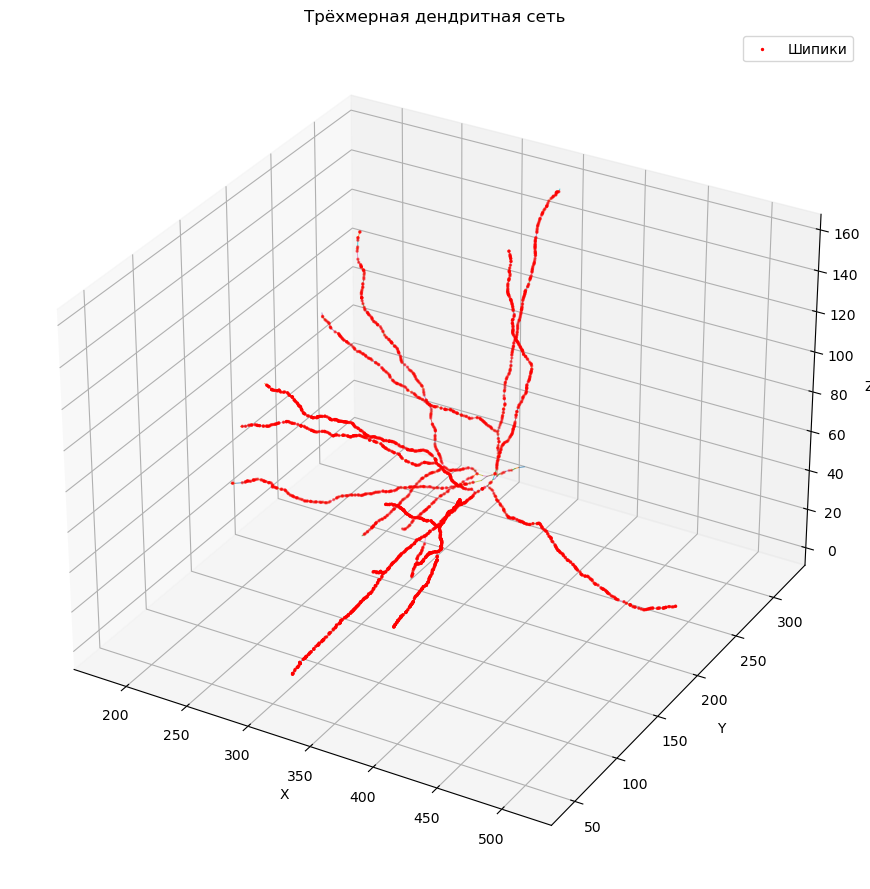

In [11]:
import matplotlib.pyplot as plt


fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

if edges is not None:
    coordinates = vertices.set_index("vertex_id")

    for edge in edges.itertuples(index=False):
        source = coordinates.loc[int(edge.source)]
        target = coordinates.loc[int(edge.target)]

        ax.plot(
            [source["x"], target["x"]],
            [source["y"], target["y"]],
            [source["z"], target["z"]],
            linewidth=0.7,
            alpha=0.7,
        )
else:
    ax.scatter(
        vertices["x"],
        vertices["y"],
        vertices["z"],
        s=2,
        label="Вершины дендрита",
    )

ax.scatter(
    spines["x"],
    spines["y"],
    spines["z"],
    s=2,
    color='red',
    label="Шипики",
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Трёхмерная дендритная сеть")
ax.legend()

plt.tight_layout()
plt.show()